## Classical ML Model #3: **Gradient Boosting Classifier**

First, we will import our pre-split and scaled training, validation, and test sets.

In [59]:
import pandas as pd
import joblib

# Load the preprocessed and scaled data
X_train_scaled = joblib.load('processed_data/X_train_scaled.pkl')
X_val_scaled = joblib.load('processed_data/X_val_scaled.pkl')
X_test_scaled = joblib.load('processed_data/X_test_scaled.pkl')

y_train = joblib.load('processed_data/y_train.pkl')
y_val = joblib.load('processed_data/y_val.pkl')
y_test = joblib.load('processed_data/y_test.pkl')

# **[4]** Model Selection Training
For the third model, we are implementing **Gradient Boosting Classifier** as an ensemble model. Unlike all other classical models implemented, we did not use Sklearn as our library. Instead, we used xgboost because compared to other libraries, this is optimized for efficiency in training models and high accuracy. Built-in factors include regularization to prevent overfitting, handling of missing values, and parallel computing capabilities. 

In theory, gradient boosting utilizes decision trees that is learned in linear sequence. It builds new trees based from learning from errors from previous decision tree to adjust hyperparameters. Compared to random forest, it is more prone to overfitting especially when regularization is not properly used, longer training time, and can consume more memory. Despite its disadvantes, it allows hhigher predictive accuracy.

**Credits**: [XGBoost Documentation](https://xgboost.readthedocs.io/en/release_3.2.0/python/python_intro.html), [XGBoost Guide to Hyperparameter Tuning](https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d), [GeeksforGeerks: Gradient Boosting vs Random Foorest](https://www.geeksforgeeks.org/machine-learning/gradient-boosting-vs-random-forest/)

In [60]:
import sys
!{sys.executable} -m pip install xgboost

import xgboost as xgb
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, log_loss,
    roc_auc_score, precision_recall_curve, auc, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

print(f'Working on XGBoost Version: {xgb.__version__}')

Defaulting to user installation because normal site-packages is not writeable
Working on XGBoost Version: 3.2.0


## Evaluation Metrics
The following will be used as evaluation metrics in assessing performances within this model.
1. Balanced Accuracy
2. Accuracy
3. Precision (Rural)
4. Precision (Urban)
5. Recall (Rural)
6. Recall (Urban)
7. F1-score (Rural)
8. F1-score (Urban)
9. Log Loss
10. Area under the receiving operating characteristic curve - ROC-AUC
11. Area under the precision recall curve - PR-AUC

These metrics are used to assess performances within the model of the following:
1. Comparison between training set and validation set using pre-tuned model fitted on training set
2. Comparison between validation set from pre-tuned model and validation set from post-tuned model
3. Post-tuned model predicting on test set

In [61]:
def get_prob_preb_loss(model, X):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    return y_prob, y_pred


def evaluate_model_comprehensive(y_prob, y_pred, y_actual):
    bal_acc = balanced_accuracy_score(y_actual, y_pred)
    acc = accuracy_score(y_actual, y_pred)
    report = classification_report(y_actual, y_pred, output_dict=True)
    loss = log_loss(y_actual, y_prob)
    roc_auc = roc_auc_score(y_actual, y_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_actual, y_prob)
    pr_auc = auc(recall_vals, precision_vals)

    data_index = {
        'Balanced Accuracy': round(bal_acc, 4),
        'Accuracy': round(acc, 4), 
        'Precision (Rural)': round(report['0']['precision'], 4), 
        'Precision (Urban)': round(report['1']['precision'], 4),
        'Recall (Rural)': round(report['0']['recall'], 4), 
        'Recall (Urban)': round(report['1']['recall'], 4), 
        'F1-score (Rural)': round(report['0']['f1-score'], 4), 
        'F1_score (Urban)': round(report['1']['f1-score'], 4),
        'Log Loss': round(loss, 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4)
    }
    return pd.DataFrame.from_dict(data_index, orient='index', columns=['Value'])

def compare_values(first_metrics, second_metrics, first_name, second_name):
    comparison_df = pd.concat([first_metrics, second_metrics], axis=1)
    comparison_df.columns = [first_name, second_name]
    
    comparison_df['Difference'] = comparison_df[second_name] - comparison_df[first_name]
    
    
    def style_diff_background(row):
        styles = [''] * len(row)
        diff_value = row['Difference']

        if diff_value == 0:
            return styles

        is_improvement = diff_value > 0
            
        color = '#c6efce' if is_improvement else '#ffc7ce' 
        text_color = '#006100' if is_improvement else '#9c0006' 
        
        styles[2] = f'background-color: {color}; color: {text_color}; font-weight: bold;'
        return styles

    return comparison_df.style.apply(style_diff_background, axis=1).format("{:.4f}")

def bar_graph(comparison_df, title, x_axis_name, y_axis_name):
    plot_data = comparison_df.drop(columns=['Difference'])
    plot_data = plot_data.reset_index().melt(id_vars='index', var_name='Model Stage', value_name='Score')
    plot_data.columns = ['Metric', 'Model Stage', 'Score']

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model Stage', palette=['#ff9999','#66b3ff'])
    

    plt.title(title, fontsize=15, pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.1) # Scores are between 0 and 1
    plt.ylabel(y_axis_name)
    plt.xlabel(x_axis_name)
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()
    

### Training Phase
Following baseline algorithm, after loading .pkl files created from `Preliminaries` notebook, we can create `XGBCLassifier` object based from xgboost library and then train on training set. The following are parameters of `XGBClassifier`:

| Parameter        | Default Value | Definition |
| -----            | -----   | ------ |
| n_estimator      | 100     | number of boosting rounds (trees) |
| learning_rate    | 0.3     | step size shrinkage to prevent overfitting  |
| max_depth        | 6       | maximum tree depth |
| subsample        | 1       | fraction of data used for training each tree |
| colsample_bytree | 1       | feature subsampling ratio per tree |
| gamma            | 0       | minimum loss function required to make a further partition on a leaf node |
| reg_alpha        | 0       | L1 regularization, encouraging sparsity |
| reg_lambda       | 1       | L2 regularization, encouraging reduction of weight size |
| objective        | binary:logistic | specifies learning task and the corresponding loss function |
| scale_pos_weight | 1        | adjusts weights for imbalanced datasets |

Applying from conceptual understanding of decision trees as prerequisite to understanding gradient boosting, the mentioned above (except `objective`) are hyperparameters where their values are need to be tuned during Tuning phase. 

**Credits**: [GeeksforGeeks: Gradient Boosting vs Random Forest](https://www.geeksforgeeks.org/machine-learning/gradient-boosting-vs-random-forest/), [IBM Developer: Implementing XGBoost on Python](https://developer.ibm.com/tutorials/awb-implement-xgboost-in-python/)

In [ ]:
pretuned_params = {
    'n_estimators': 100,
    'learning_rate': 0.3,
    'max_depth': 6,
    'subsample': 1,
    'colsample_bytree': 1,
    'gamma': 0,
    'scale_pos_weight': 1
}

pretuned_xgb_model = xgb.XGBClassifier()
pretuned_xgb_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

With pre-tuned model, we are going to test it on training set and get training errors.

In [63]:
y_pretuned_prob_train, y_pretuned_pred_train = get_prob_preb_loss(model=pretuned_xgb_model, X=X_train_scaled)
y_pretuned_metrics_train = evaluate_model_comprehensive(y_prob=y_pretuned_prob_train, y_pred=y_pretuned_pred_train, y_actual=y_train)

### Testing if trained model is an overfit
After training the pre-tuned model using training set, we can test if this works well with validation set. If a trained model performs well on training set (low training error) but not on validation set (high training error), then it is most likely to be an overfit.

In [64]:
y_pretuned_prob_val, y_pretuned_pred_val = get_prob_preb_loss(model=pretuned_xgb_model, X=X_val_scaled)
y_pretuned_metrics_val = evaluate_model_comprehensive(y_prob=y_pretuned_prob_val, y_pred=y_pretuned_pred_val, y_actual=y_val)

From the table and bar graph below, we can see that all metrics (except loss) of pre-tuned model has higher score on train set as compared to test set. For loss, in Binary Cros entropy (BCE), the higher the value is, the poorer the performance of the model and vice versa. Without using statistical test, we can clearly see that because all metrics perform better on training set than on validation set, we can say that the pre-tuned model is an **overfit**.

Connecting to theoretical concept, gradient boosting utilizes decision trees that are highly prone to overfitting when trained in linear sequence. As such, decision trees grow greedily that captures every noise on data rather than following on general trends. It performs poorly on unseen validation set as new data.  

,Pretuned Train,Pretuned Val,Difference
Balanced Accuracy,0.9137,0.7953,-0.1184
Accuracy,0.9254,0.8165,-0.1089
Precision (Rural),0.9195,0.8289,-0.0906
Precision (Urban),0.9360,0.7924,-0.1436
Recall (Rural),0.9634,0.8855,-0.0779
Recall (Urban),0.8640,0.7051,-0.1589
F1-score (Rural),0.9409,0.8563,-0.0846
F1_score (Urban),0.8986,0.7462,-0.1524
Log Loss,0.2183,0.3930,0.1747
ROC-AUC,0.9793,0.8905,-0.0888


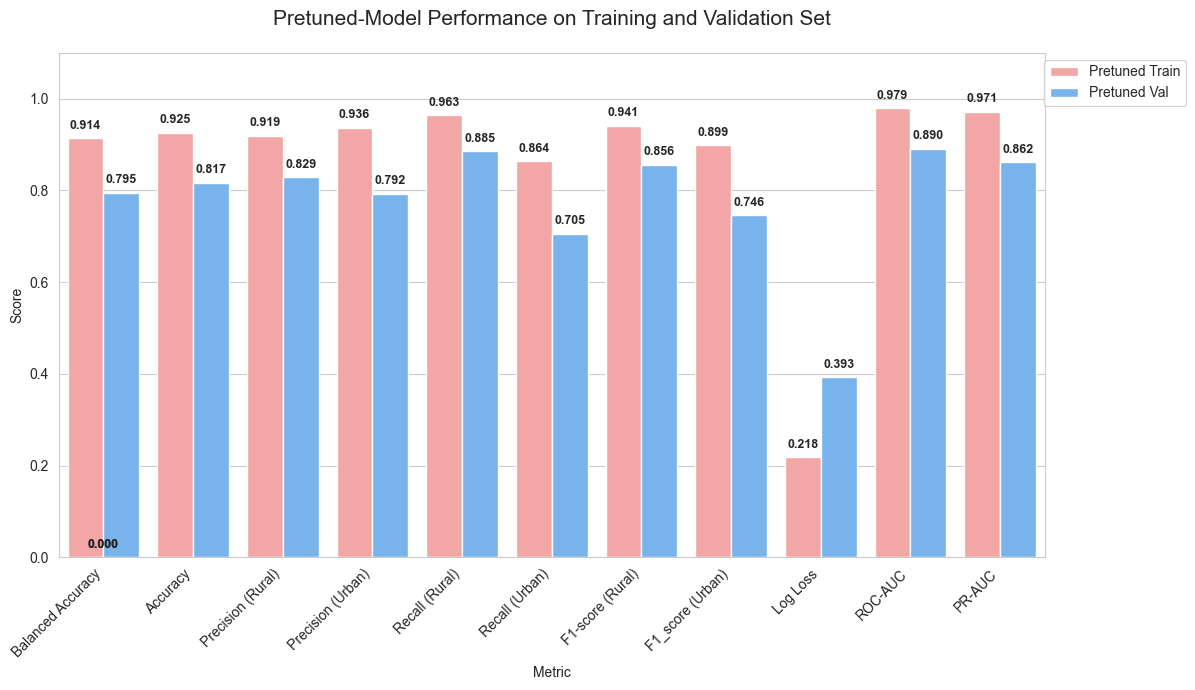

In [65]:
# code to compare performances between training set and validation set and then tell if this is an overfit
compare_pretrain_vs_preval = compare_values(first_metrics=y_pretuned_metrics_train, 
                                                second_metrics=y_pretuned_metrics_val, 
                                                first_name='Pretuned Train', 
                                                second_name='Pretuned Val')
display(compare_pretrain_vs_preval)
bar_graph(comparison_df=compare_pretrain_vs_preval.data, 
          title= 'Pretuned-Model Performance on Training and Validation Set', 
          x_axis_name = 'Metric', 
          y_axis_name = 'Score')

# **[5]** Hyperparameter Tuning
Aimed in improving the performance of a model, this phase uses data from validation set to find the best set of possible hyperparameters in optimizing the model's performance. This method uses random search algorithm using `RandomSearchCV` library wherein each hyperparamaters are arbitrarily picked from random set of possible values using `stats` package. The best set of hyperparameters are used in creating another model.

Credits: [Medium: XGBoost Guide to Hyperparameter Tuning](https://medium.com/@dicee/optimizing-xgboost-a-guide-to-hyperparameter-tuning-77b6e48e289d), [GeeksForGeeks: XGBClassifier in Machine Learning](https://www.geeksforgeeks.org/machine-learning/xgbclassifier/)

In [66]:
param_dist = {
    'n_estimators': stats.randint(100, 200),
    'learning_rate': stats.uniform(0.01, 0.2),
    'max_depth': stats.randint(3, 10),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'gamma': stats.uniform(0.0, 0.5),
    'scale_pos_weight': stats.uniform(0.5, 0.5)
}


# Defining randoms and training it
random_search = RandomizedSearchCV(
    estimator=pretuned_xgb_model, 
    param_distributions=param_dist, 
    n_iter=10,
    scoring='f1', 
    n_jobs=-1,
    refit=True,
    cv=5,  
    random_state=42
)
random_search.fit(X_train_scaled, y_train)


# Displaying best set of hyperparameters and corresponding score
posttuned_params = random_search.best_params_
posttuned_xgb_model = xgb.XGBClassifier(**posttuned_params)
posttuned_xgb_model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6964101864104046
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

Changes of values of hyperparameters from pre-tuned model to post-tuned model

In [67]:
# Code to compare how values of hyperparameter changed from pre-tuned model to post-tuned model
pretuned_params_df = pd.DataFrame.from_dict(pretuned_params, orient='index', columns=['Value'])
posttuned_params_df = pd.DataFrame.from_dict(posttuned_params, orient='index', columns=['Value'])
params_df = compare_values(pretuned_params_df, posttuned_params_df, 'Pre-tuned', 'Post-tuned')
display(params_df)

,Pre-tuned,Post-tuned,Difference
n_estimators,100.0000,134.0000,34.0000
learning_rate,0.3000,0.1320,-0.1680
max_depth,6.0000,9.0000,3.0000
subsample,1.0000,0.7035,-0.2965
colsample_bytree,1.0000,0.6964,-0.3036
gamma,0.0000,0.3416,0.3416
scale_pos_weight,1.0000,0.9547,-0.0453


## Comparison of performances between pre-tuned and post-tuned model

We are now going to compare and determine if post-tuned model fitted on train set performs better than pre-tuned model fitted on train set. From the table and bar graph below, there are very little differences on each metric between post-tuend model and pre-tuned model. They display identical performance because both models have already achieved maximum capacity to memorize or fit the specific patterns within that limited data.

In [68]:
y_posttuned_prob_val, y_posttuned_pred_val = get_prob_preb_loss(model=posttuned_xgb_model, X=X_val_scaled)
y_posttuned_metrics_val = evaluate_model_comprehensive(y_prob=y_posttuned_prob_val, y_pred=y_posttuned_pred_val, y_actual=y_val)

,Pretuned Val,Posttuned Val,Difference
Balanced Accuracy,0.7953,0.7922,-0.0031
Accuracy,0.8165,0.8143,-0.0022
Precision (Rural),0.8289,0.8257,-0.0032
Precision (Urban),0.7924,0.7919,-0.0005
Recall (Rural),0.8855,0.8863,0.0008
Recall (Urban),0.7051,0.6982,-0.0069
F1-score (Rural),0.8563,0.8549,-0.0014
F1_score (Urban),0.7462,0.7421,-0.0041
Log Loss,0.3930,0.3954,0.0024
ROC-AUC,0.8905,0.8907,0.0002


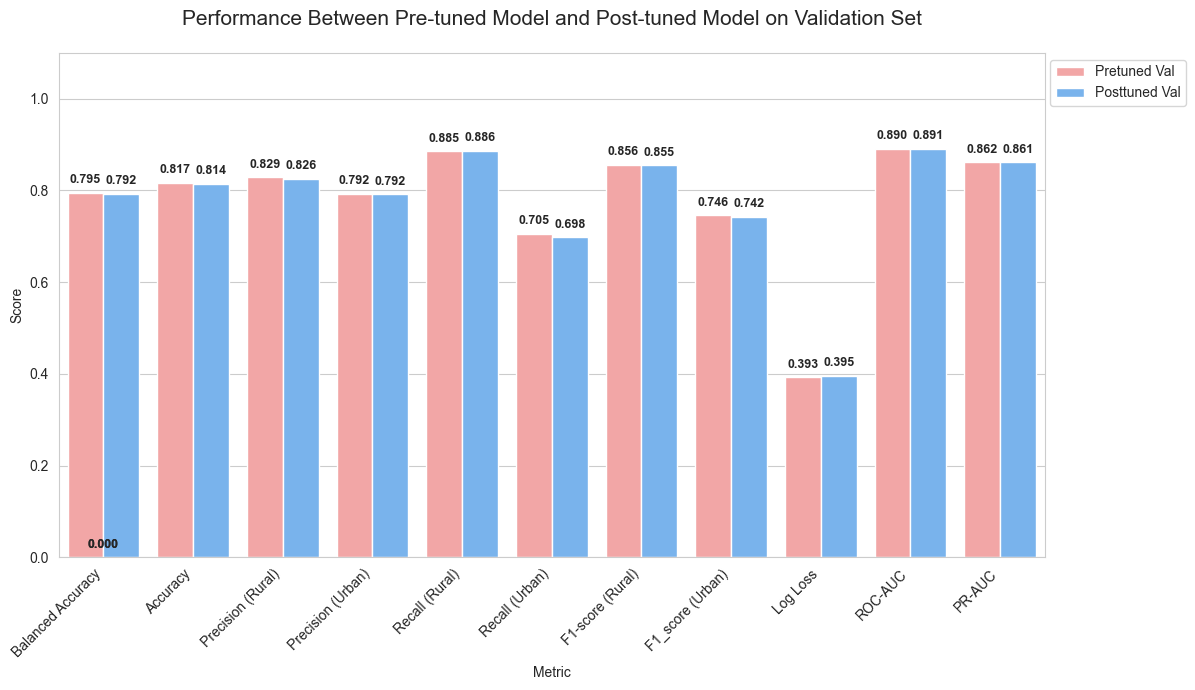

In [69]:
# Code to compare performances between pre-tuned and post-tuned model
compare_preval_vs_postval = compare_values(first_metrics=y_pretuned_metrics_val, 
                                                second_metrics=y_posttuned_metrics_val, 
                                                first_name='Pretuned Val', 
                                                second_name='Posttuned Val')
display(compare_preval_vs_postval)
bar_graph(comparison_df=compare_preval_vs_postval.data, 
          title='Performance Between Pre-tuned Model and Post-tuned Model on Validation Set', 
          x_axis_name = 'Metric', 
          y_axis_name = 'Score')

# **[6]** Model Evaluation
The testing phase serves as final performance of using tuned model to predict values on training set.

In [70]:
y_posttuned_prob_test, y_posttuned_pred_test = get_prob_preb_loss(model=posttuned_xgb_model, X=X_test_scaled)
y_posttuned_metrics_test = evaluate_model_comprehensive(y_prob=y_posttuned_prob_test, y_pred=y_posttuned_pred_test, y_actual=y_test)
display(y_posttuned_metrics_test)

,Value
Balanced Accuracy,0.7986
Accuracy,0.8213
Precision (Rural),0.8290
Precision (Urban),0.8059
Recall (Rural),0.8952
Recall (Urban),0.7021
F1-score (Rural),0.8608
F1_score (Urban),0.7504
Log Loss,0.3859
ROC-AUC,0.8961


Exporting test results from model to `model_outputs` folder. This is used to compare with other performances.

In [71]:
import os

os.makedirs('model_outputs', exist_ok=True)

# Save the final locked-in model
joblib.dump(posttuned_xgb_model, 'model_outputs/gradient_boosting_final_model.pkl')

# Create a DataFrame of the Test Set predictions and probabilities
GB_test_results = pd.DataFrame({
    'Actual_y_test': y_test,
    'GB_Predicted_Class': y_posttuned_pred_test,
    'GB_Predicted_Probability': y_posttuned_prob_test
})

# Export to CSV for easy comparison in the main directory
GB_test_results.to_csv('model_outputs/gb_test_predictions.csv', index=False)